# PRVNÍ PREDIKCE - Porucha do 72h

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("../data/ML/Predictive_Dataset.csv", parse_dates=["timestamp"])

df.head()

,timestamp,machine_id,temperature,vibration,pressure,load,ambient_temperature,is_running,produced_units,defective_units,...,rolling_vibration_std_24h,rolling_pressure_mean_24h,rolling_pressure_std_24h,running_ratio_24h,hours_since_last_failure,failure_count_last_7d,failure_count_last_30d,target_failure_72h,target_failure_type,target_RUL_hours
0,2022-01-01 00:00:00,1,49.3,2.28,4.61,89.27,17.8,1,120,2,...,NaN,NaN,NaN,NaN,NaN,0,0,0,mechanical,1617.0
1,2022-01-01 01:00:00,1,50.9,2.02,5.23,73.30,19.3,1,116,0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,mechanical,1616.0
2,2022-01-01 02:00:00,1,48.2,1.80,5.25,86.79,18.6,1,117,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,mechanical,1615.0
3,2022-01-01 03:00:00,1,49.8,2.65,4.92,69.77,18.9,1,116,2,...,NaN,NaN,NaN,NaN,NaN,0,0,0,mechanical,1614.0
4,2022-01-01 04:00:00,1,46.3,2.20,5.15,84.98,17.9,1,115,0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,mechanical,1613.0


In [2]:
df.columns

Index(['timestamp', 'machine_id', 'temperature', 'vibration', 'pressure',
       'load', 'ambient_temperature', 'is_running', 'produced_units',
       'defective_units', 'operating_hours_since_maintenance',
       'machine_age_hours', 'health_index', 'health_delta_24h',
       'rolling_temp_mean_24h', 'rolling_temp_std_24h',
       'rolling_vibration_mean_24h', 'rolling_vibration_std_24h',
       'rolling_pressure_mean_24h', 'rolling_pressure_std_24h',
       'running_ratio_24h', 'hours_since_last_failure',
       'failure_count_last_7d', 'failure_count_last_30d', 'target_failure_72h',
       'target_failure_type', 'target_RUL_hours'],
      dtype='str')

In [3]:
df_model = df.copy()

# Odstranit hodnoty, kde je target 0.
df_model = df.dropna(subset=["target_failure_72h"])

# Doplnění hodnot, kde je hours_since_last_failure pomocí machine_age_hours
df_model["hours_since_last_failure"] = df_model["hours_since_last_failure"].fillna(df["machine_age_hours"])

# Výběr features bez nepotřebných sloupců.
features = df_model.columns.drop([
    "timestamp",
    "machine_id",
    "target_failure_72h",
    "target_failure_type",
    "target_RUL_hours",
    "health_index",  # chceme vynechat
    "produced_units",
    "defective_units"
]).tolist()



In [4]:
df_model.shape

(315372, 27)

In [5]:
df_model.isnull().sum()

timestamp                               0
machine_id                              0
temperature                             0
vibration                               0
pressure                                0
load                                    0
ambient_temperature                     0
is_running                              0
produced_units                          0
defective_units                         0
operating_hours_since_maintenance       0
machine_age_hours                       0
health_index                            0
health_delta_24h                      288
rolling_temp_mean_24h                 276
rolling_temp_std_24h                  276
rolling_vibration_mean_24h            276
rolling_vibration_std_24h             276
rolling_pressure_mean_24h             276
rolling_pressure_std_24h              276
running_ratio_24h                     276
hours_since_last_failure                0
failure_count_last_7d                   0
failure_count_last_30d            

In [6]:
# Odstranění NaN hodnot rolling features
df_model = df_model.dropna(subset=features)

In [7]:
df_model.shape

(315084, 27)

In [8]:
df_model.isnull().sum()

timestamp                               0
machine_id                              0
temperature                             0
vibration                               0
pressure                                0
load                                    0
ambient_temperature                     0
is_running                              0
produced_units                          0
defective_units                         0
operating_hours_since_maintenance       0
machine_age_hours                       0
health_index                            0
health_delta_24h                        0
rolling_temp_mean_24h                   0
rolling_temp_std_24h                    0
rolling_vibration_mean_24h              0
rolling_vibration_std_24h               0
rolling_pressure_mean_24h               0
rolling_pressure_std_24h                0
running_ratio_24h                       0
hours_since_last_failure                0
failure_count_last_7d                   0
failure_count_last_30d            

In [9]:
# Seřazení dat
df_model = df_model.sort_values("timestamp")

# Split podle času
split_time = df_model["timestamp"].quantile(0.8)

train = df_model[df_model["timestamp"] < split_time]
test = df_model[df_model["timestamp"] >= split_time]

# Vytvoření X a y
X_train = train[features]
y_train = train["target_failure_72h"]

X_test = test[features]
y_test = test["target_failure_72h"]

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# škálování
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# model
model_lr = LogisticRegression(max_iter=2000)
model_lr.fit(X_train_scaled, y_train)

pred_lr = model_lr.predict(X_test_scaled)

In [11]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

In [12]:
from sklearn.metrics import classification_report

print("Logistic Regression:")
print(classification_report(y_test, pred_lr))

print("Random Forest:")
print(classification_report(y_test, pred_rf))

Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     56475
           1       0.52      0.99      0.68      6549

    accuracy                           0.90     63024
   macro avg       0.76      0.94      0.81     63024
weighted avg       0.95      0.90      0.92     63024

Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     56475
           1       0.57      0.95      0.71      6549

    accuracy                           0.92     63024
   macro avg       0.78      0.93      0.83     63024
weighted avg       0.95      0.92      0.93     63024



In [13]:
from sklearn.ensemble import RandomForestClassifier

model_rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model_rf_tuned.fit(X_train, y_train)

pred_rf_tuned = model_rf_tuned.predict(X_test)

In [14]:
from sklearn.metrics import classification_report

print("Random Forrest:")
print(classification_report(y_test, pred_rf))

print("Random Forest Tuned:")
print(classification_report(y_test, pred_rf_tuned))

Random Forrest:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     56475
           1       0.57      0.95      0.71      6549

    accuracy                           0.92     63024
   macro avg       0.78      0.93      0.83     63024
weighted avg       0.95      0.92      0.93     63024

Random Forest Tuned:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     56475
           1       0.60      0.92      0.73      6549

    accuracy                           0.93     63024
   macro avg       0.80      0.93      0.84     63024
weighted avg       0.95      0.93      0.94     63024



Výsledky RF vycházejí lépe.

In [15]:
importance = model_rf.feature_importances_

feat_importance = pd.Series(importance, index=features)
feat_importance.sort_values(ascending=False).head(10)

machine_age_hours                    0.202750
rolling_vibration_mean_24h           0.198216
rolling_pressure_mean_24h            0.127471
health_delta_24h                     0.079798
hours_since_last_failure             0.070177
operating_hours_since_maintenance    0.068009
rolling_temp_mean_24h                0.059621
vibration                            0.036274
rolling_pressure_std_24h             0.022917
rolling_temp_std_24h                 0.022745
dtype: float64

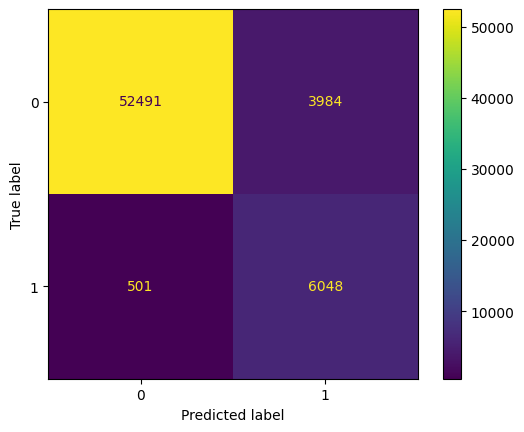

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, pred_rf_tuned)

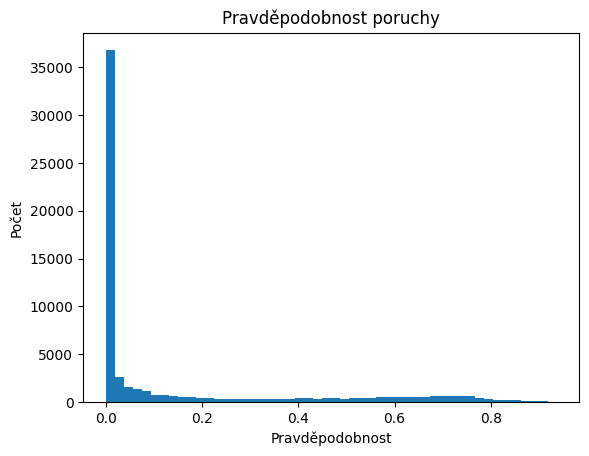

In [17]:
probs = model_rf_tuned.predict_proba(X_test)[:,1]

import matplotlib.pyplot as plt

plt.hist(probs, bins=50)
plt.title("Pravděpodobnost poruchy")
plt.xlabel("Pravděpodobnost")
plt.ylabel("Počet")
plt.show()

<Axes: xlabel='timestamp'>

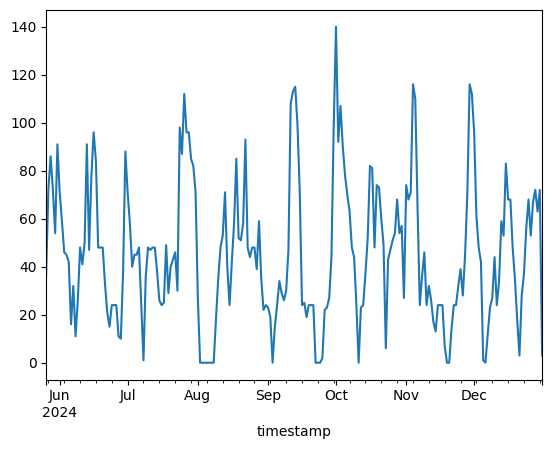

In [18]:
test_results = test.copy()
test_results["prediction"] = pred_rf_tuned
test_results.set_index("timestamp")["prediction"].resample("D").sum().plot()

In [19]:
test_results = test.copy()
test_results["prediction"] = pred_rf_tuned
test_results.groupby("machine_id")["prediction"].mean()

machine_id
1     0.118050
2     0.206398
3     0.171173
4     0.106626
5     0.179551
6     0.244097
7     0.117098
8     0.184120
9     0.186596
10    0.133283
11    0.101866
12    0.161272
Name: prediction, dtype: float64

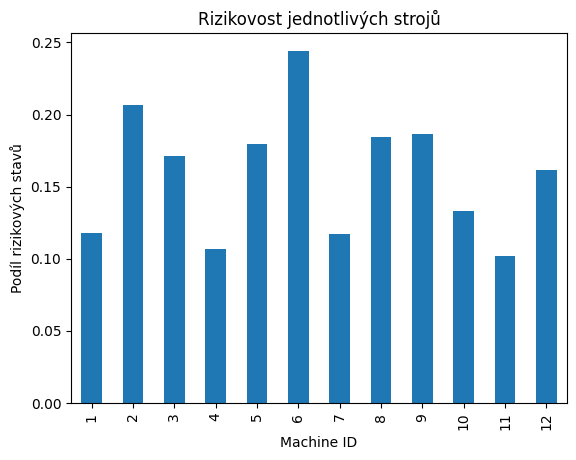

In [20]:
import matplotlib.pyplot as plt

risk = test_results.groupby("machine_id")["prediction"].mean()

risk.plot(kind="bar")
plt.title("Rizikovost jednotlivých strojů")
plt.xlabel("Machine ID")
plt.ylabel("Podíl rizikových stavů")
plt.show()

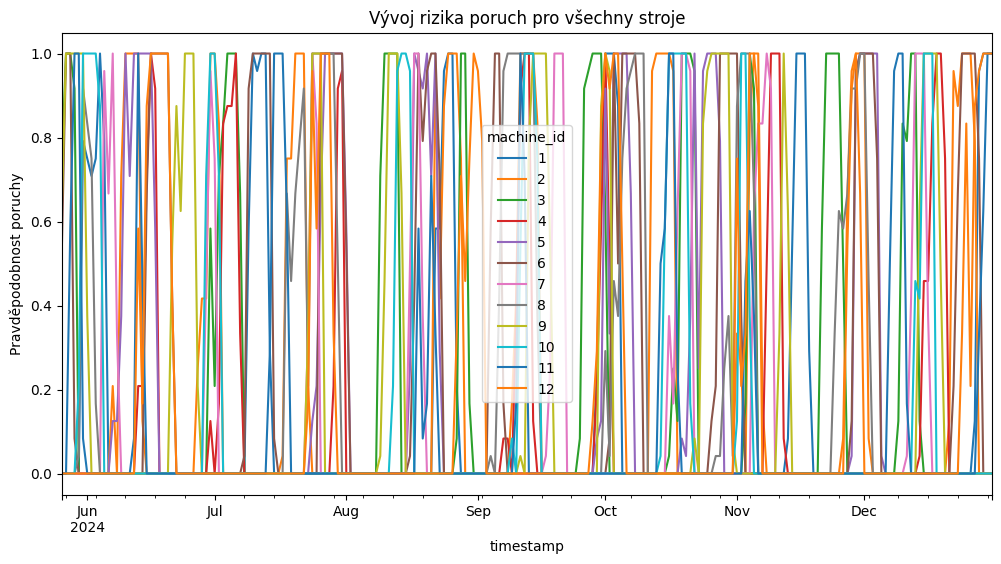

In [21]:
pivot = test_results.pivot_table(
    index="timestamp",
    columns="machine_id",
    values="prediction"
)

pivot.resample("D").mean().plot(figsize=(12,6))
plt.title("Vývoj rizika poruch pro všechny stroje")
plt.ylabel("Pravděpodobnost poruchy")
plt.show()

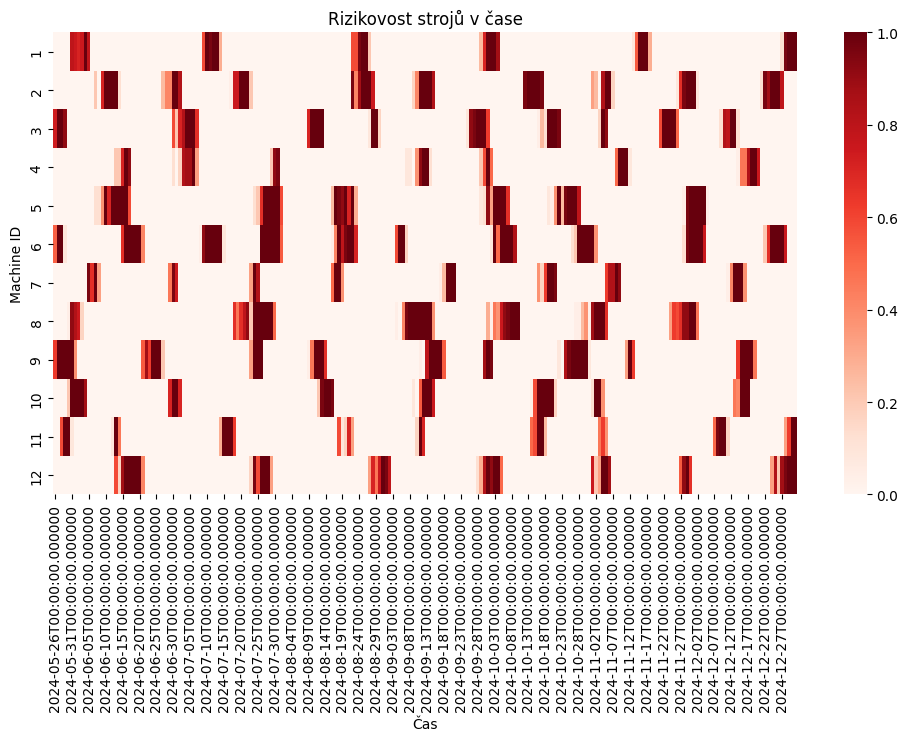

In [22]:
import seaborn as sns

pivot_daily = pivot.resample("D").mean()

plt.figure(figsize=(12,6))
sns.heatmap(pivot_daily.T, cmap="Reds")
plt.title("Rizikovost strojů v čase")
plt.xlabel("Čas")
plt.ylabel("Machine ID")
plt.show()